## 타이타닉 탑승자 명단을 사용하여 타이타닉 데이터 분석 및 생존자 예측
#### 문제 정의하기
**타이타닉 탑승자 명단** 을 통해 생존자 분석 
* 1912년 4월 10일 영국 Southampton에서 출발하고 5일 후, 1912년 4월 15일 침몰
* 이진 분류 예제에 적합한 데이터셋 중 6개 변수, 1개 변수는 생존 결과로 1이면 생존, 0이면 사망
* → 6개 변수를 독립변수로 보고 생존 유무를 예측하는 이진 분류 문제로 정의



#### 데이터 칼럼 소개
* Survived : 생존 여부 (0 = 사망, 1 = 생존)
* Pclass : 티켓 클래스 (1 = 1등석, 2 = 2등석, 3 = 3등석)
* Sex : 성별
* Age : 나이
* SibSp : 함께 탑승한 자녀 / 배우자 의 수
* Parch : 함께 탑승한 부모님 / 아이들 의 수
* Ticket : 티켓 번호
* Fare : 탑승 요금
* Cabin : 수하물 번호
* Embarked : 선착장 (C = Cherbourg, Q = Queenstown, S = Southampton)

In [1]:
# 필요한 라이브러리 호출하기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### 1. 데이터에 대한 기본적인 EDA

In [2]:
# 데이터 불러오기
titanic_df = pd.read_csv('/Users/gimdogyun/Desktop/코드/Titanic-Dataset.csv')


In [3]:
# 1. 데이터에서 head() 함수를 사용해서 상위 5개의 행을 출력한다
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 2. 데이터에서 info() 함수를 사용해서 데이터의 정보를 출력한다
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# 3. 데이터에서 describe() 함수를 사용해서 통계 정보를 출력한다
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# 4. 데이터에서 isnull() 함수를 사용해서 결측치를 확인한다
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### 기본적인 EDA를 통해서 알 수 있는 것은 무엇이 있을까?

* 본인의 생각을 적어보세요



#### 2. EDA를 통해 여러가지 가설을 검증해본다.

#### 1. 타이타닉호의 생존자,사망자 비율은 어떻게 되는가?? 

* 본인의 생각을 적어보세요

In [7]:
# 타이타닉 호의 생존자 수와 사망자 수 확인하기
titanic_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

사망 비율은 61.6%, 생존 비율은 38.4%로 사망한 탑승객의 수가 더 많은 것이 확인 된다.


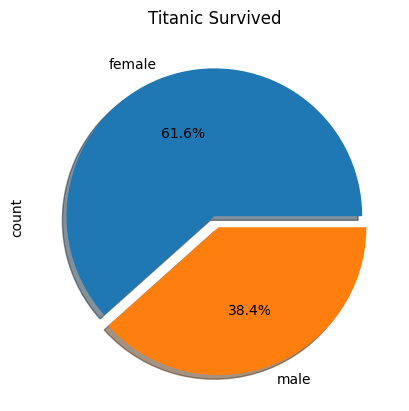

In [8]:
# 타이타닉 호의 생존자 수와 사망자 수를 시각화한다

titanic_df['Survived'].value_counts().plot.pie(explode=[0, 0.08], 
                                          shadow=True,
                                          autopct='%1.1f%%',
                                          labels=['female','male'])

plt.title('Titanic Survived')
print('사망 비율은 61.6%, 생존 비율은 38.4%로 사망한 탑승객의 수가 더 많은 것이 확인 된다.')

#### 2. 성별에 따른 생존, 사망 비율이 다를까?

* 본인의 생각을 적어보세오

In [9]:
# 타이타닉 호의 성별 확인하기
titanic_df['Sex'].value_counts()

# 타이타닉 호의 성별 생존자수 확인하기
titanic_df[['Sex', 'Survived']].groupby('Sex').sum()
#.groupby('Sex').mean()
#.groupby('Sex').mean()

,Survived
Sex,
female,233
male,109


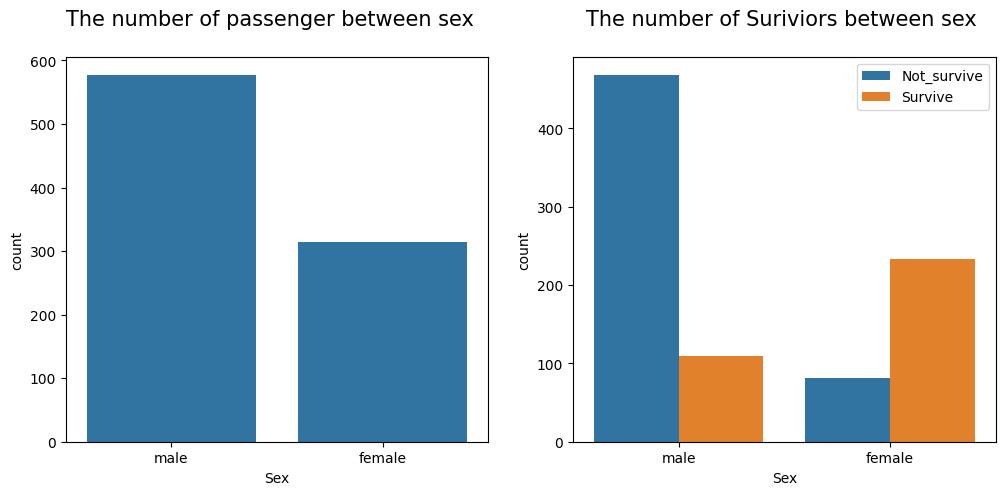

In [10]:
# 타이타닉 호의 성별 비율 및 성별에 따른 생존자 수 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("The number of passenger between sex  \n", size=15)
sns.countplot(x="Sex", data=titanic_df, ax=axes[0])

axes[1].set_title("The number of Suriviors between sex \n", size=15)
sns.countplot(x="Sex", hue="Survived", data=titanic_df, ax=axes[1])
axes[1].legend(labels = ['Not_survive', 'Survive'])

#### 3. 티켓 클래스(Pclass)별로 생존율에 차이가 날까?

* 본인의 생각을 적어보세요

In [11]:
# 객실 등급 수 확인하기
titanic_df['Pclass'].value_counts(normalize=True)

# 타이타닉 호의 객실 등급 생존자수 확인하기
titanic_df[['Pclass', 'Survived']].groupby('Pclass').mean()


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


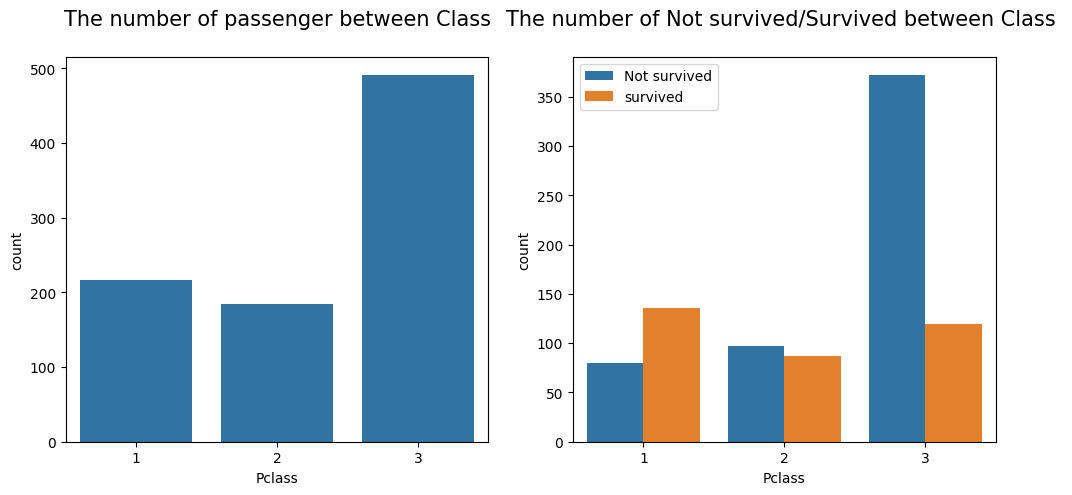

In [12]:
# 타이타닉 호의 객실 등급 비율 및 객실 등급에 따른 생존자 수 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("The number of passenger between Class\n", size=15)
sns.countplot(data=titanic_df, x='Pclass', ax=axes[0])

axes[1].set_title("The number of Not survived/Survived between Class \n", size=15)
sns.countplot(x="Pclass", hue="Survived", data=titanic_df, ax=axes[1])
axes[1].legend(labels = ['Not survived', 'survived'])

#### 4. 항구별로 사망자 차이가 날까?

* 본인의 생각을 적어보세요

In [13]:
# 객실 등급 수 확인하기
titanic_df['Embarked'].value_counts(normalize=True)

# 타이타닉 호의 객실 등급 생존자수 확인하기
titanic_df[['Embarked', 'Survived']].groupby('Embarked').mean()


,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


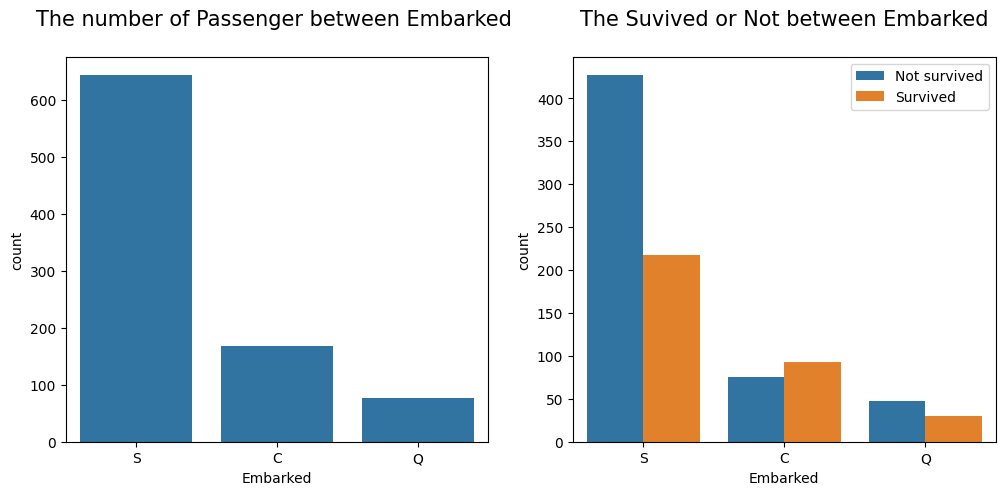

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("The number of Passenger between Embarked \n", size=15)
sns.countplot(x="Embarked", data=titanic_df, ax=axes[0])

axes[1].set_title("The Suvived or Not between Embarked\n", size=15)
sns.countplot(x="Embarked", hue="Survived", data=titanic_df, ax=axes[1])
axes[1].legend(labels = ['Not survived', 'Survived'])

In [15]:
titanic_df[titanic_df['Pclass'] == 1]['Embarked'].value_counts(normalize=True)


Embarked
S    0.593458
C    0.397196
Q    0.009346
Name: proportion, dtype: float64

<Axes: >

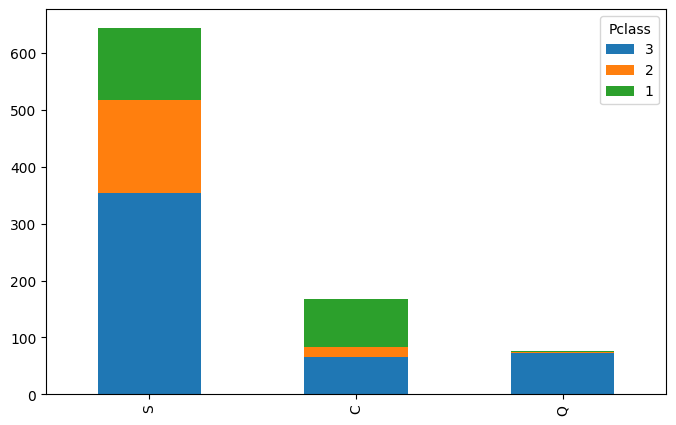

In [16]:
pc1 = titanic_df[titanic_df['Embarked'] == 'S']['Pclass'].value_counts()
pc2 = titanic_df[titanic_df['Embarked'] == 'C']['Pclass'].value_counts()
pc3 = titanic_df[titanic_df['Embarked'] == 'Q']['Pclass'].value_counts()
pc = pd.DataFrame([pc1, pc2, pc3])
pc.index = ['S', 'C', 'Q']

fig, ax = plt.subplots(figsize=(8, 5))
pc.plot(kind='bar', stacked=True, ax=ax)

#### 5. 나이에 따른 생존율 차이가 날까?

* 본인의 생각을 적어보세요

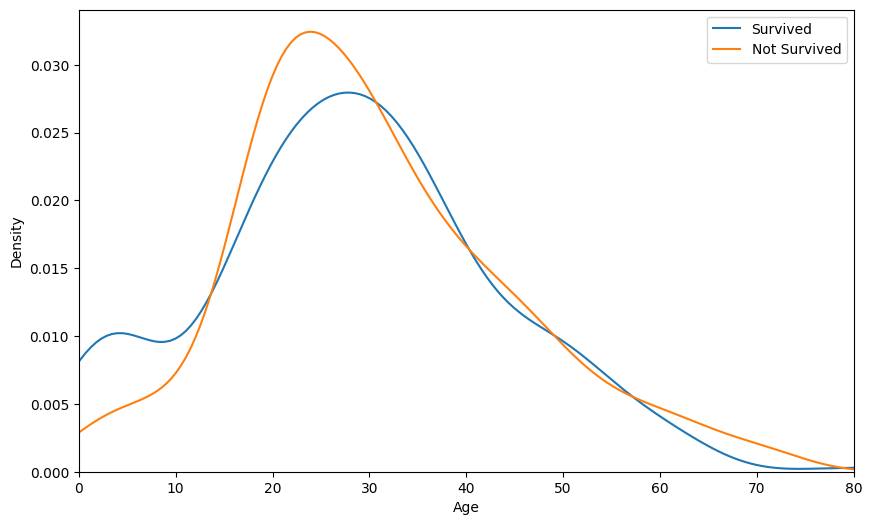

In [17]:
# 나이에 따른 생존자 수 비율 시각화

fig, ax = plt.subplots(figsize=(10,6))
 
# 분포 확인
sns.kdeplot(titanic_df[titanic_df['Survived']==1]['Age'], ax=ax)
sns.kdeplot(titanic_df[titanic_df['Survived']==0]['Age'], ax=ax)
 
# 축 범위
ax.set(xlim=(0, titanic_df['Age'].max()))
ax.legend(['Survived', 'Not Survived'])
 
plt.show()

#### 6. 탑승 금액에 따른 생존율 차이가 날까?

* 본인의 생각을 적어보세요

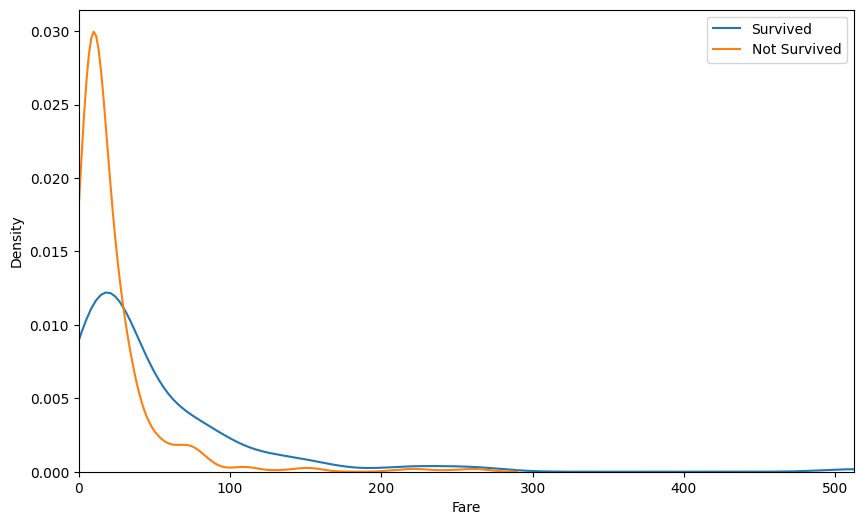

In [18]:
fig, ax = plt.subplots(figsize=(10,6))
 
# 분포 확인
sns.kdeplot(titanic_df[titanic_df['Survived']==1]['Fare'], ax=ax)
sns.kdeplot(titanic_df[titanic_df['Survived']==0]['Fare'], ax=ax)
 
# 축 범위
ax.set(xlim=(0, titanic_df['Fare'].max()))
ax.legend(['Survived', 'Not Survived'])
 
plt.show()

#### 두번째 EDA를 통해 알 수 있는 점은 무엇이 있을까?

* 본인의 생각을 적어보세요